# Monte Carlo Simulation
**Dataset:** `issues_clean.csv`  
**Variabel:** `close_time_days`  
**Pertanyaan:** Berapakah probabilitas sebuah Issue yang dipilih secara acak membutuhkan waktu lebih dari 30 hari untuk diselesaikan?  
**Metode:** Simulasi Monte Carlo via empirical resampling pada variabel `close_time_days`.  

---

## Langkah-langkah simulasi

1. Import library yang dibutuhkan.
2. Ambil dan bersihkan variabel `close_time_days` dari dataset `issues_clean.csv`.
3. Ambil sampel empiris dengan pengembalian (`replace=True`) dari nilai `close_time_days`.
4. Hitung proporsi sampel yang lebih dari 30 hari.
5. Ulangi untuk banyak iterasi dan gunakan rata-rata proporsi sebagai estimasi probabilitas.
6. Tambahkan interval kepercayaan `(95%)` dari distribusi proporsi simulasi.

---

1. Import library yang dibutuhkan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


2. Ambil data issue yang sudah dibersihkan dan drop data close_time_days yang invalid

In [3]:
# ambil data issue
df = pd.read_csv('../data/clean/issues_clean.csv')

# drop data close_time_days yang invalid
close_time_days = df['close_time_days'].dropna().values
len(close_time_days)

5000

3. Ambil sampel empiris dengan pengembalian (`replace=True`) dari nilai `close_time_days`

In [4]:
sample_demo = np.random.choice(close_time_days, size=len(close_time_days), replace=True)
print('Contoh proporsi >30 hari (satu resample):', np.mean(sample_demo > 30))

Contoh proporsi >30 hari (satu resample): 0.1684


4. Buat parameter simulasi 

In [5]:
# 4. Parameter simulasi
n_sim = 10000
sample_size = len(close_time_days)
results = np.empty(n_sim, dtype=float)

5. Ulangi untuk banyak iterasi dan gunakan rata-rata proporsi sebagai estimasi probabilitas

In [6]:
# 5. Monte Carlo (empirical resampling)
for i in range(n_sim):
    sample = np.random.choice(close_time_days, size=sample_size, replace=True)
    results[i] = np.mean(sample > 30)

6. Tambahkan interval kepercayaan `(95%)` dari distribusi proporsi simulasi

In [7]:
# 6. Hitung estimasi dan interval kepercayaan 95%
estimate = results.mean()
ci_lower, ci_upper = np.percentile(results, [2.5, 97.5])
print(f'Estimasi probabilitas issue > 30 hari: {estimate:.4f}')
print(f'95% interval kepercayaan: {ci_lower:.4f} - {ci_upper:.4f}')

Estimasi probabilitas issue > 30 hari: 0.1676
95% interval kepercayaan: 0.1574 - 0.1778


Visualisasi

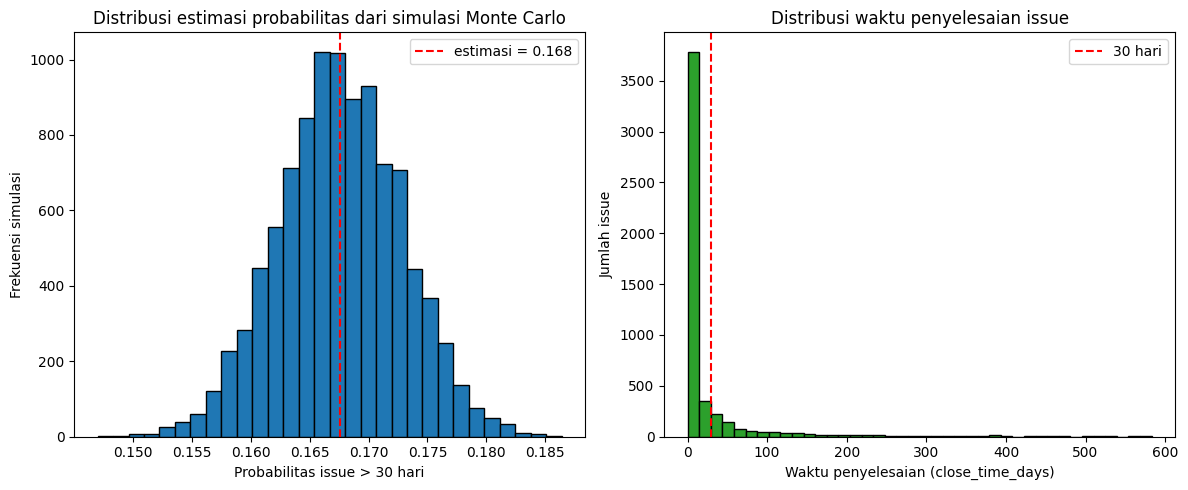

In [8]:
# Visualisasi: distribusi hasil simulasi dan distribusi waktu penyelesaian
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(results, bins=30, color='tab:blue', edgecolor='black')
plt.axvline(estimate, color='red', linestyle='--', label=f'estimasi = {estimate:.3f}')
plt.xlabel('Probabilitas issue > 30 hari')
plt.ylabel('Frekuensi simulasi')
plt.title('Distribusi estimasi probabilitas dari simulasi Monte Carlo')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(close_time_days, bins=40, color='tab:green', edgecolor='black')
plt.axvline(30, color='red', linestyle='--', label='30 hari')
plt.xlabel('Waktu penyelesaian (close_time_days)')
plt.ylabel('Jumlah issue')
plt.title('Distribusi waktu penyelesaian issue')
plt.legend()

plt.tight_layout()
plt.show()